# Tutorial 3: Raw Image Loading

Before starting, make sure that instances of `pygid.ExpParams` and `pygid.CoordMaps` have been successfully created (see [Tutorial 1](tutorial_01_experimental_parameters.ipynb) and [Tutorial 2](tutorial_02_coordinate_maps_and_corrections.ipynb)).


In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_03")
    poni_path = files["poni_for_tiff"]
    # several files for batch processing
    data_path1 = files["data1_tiff"]
    data_path2 = files["data2_tiff"]
    data_path3 = files["data3_tiff"]
except:
    print("Dataset download skipped on Read the Docs.")

In [2]:
import pygid

params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    ai=0.01                       # angle of incidence (degrees)
)

matrix = pygid.CoordMaps(
    params  # pygid.ExpParams
)


After creating the `pygid.CoordMaps` instance, raw detector images can be loaded. You can provide either the path to a raw data file (or list of files) or a 2D/3D numpy array.

## Load Image from File (EDF, TIFF, CBF)

Single file:

In [3]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path1                  # path to the raw data file
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (1, 2048, 2048)


Multiple files:

In [6]:
analysis = pygid.Conversion(
    matrix=matrix,
    path=[data_path1, data_path2, data_path3] # several files
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (3, 2048, 2048)


Note: If the number of images exceeds batch_size, batch processing mode activates (see [Tutorial 8](tutorial_08_batch_processing.ipynb)).

## Load Dataset from File (HDF5, NXS)

HDF5 and NXS files can contain multiple images with internal structure.
Specify the dataset path (e.g., `'measurement/eiger4m'`) and the frame number (`frame_num`):

- `None` – load all images
- `int` – load a single frame
- `list` – load a list of frames




In [5]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
files = get_dataset("tutorial_03")
poni_path = files["poni_for_h5"]
mask_path = files["mask_for_h5"]
# several files for batch processing
data_path = files["data_h5"]

In [6]:
import pygid

params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

matrix = pygid.CoordMaps(
    params  # pygid.ExpParams
)

Load all frames from the dataset:

In [7]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data'  # dataset path
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (13, 2162, 2068)


Load a specific frame from the dataset:

In [8]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    frame_num = 7,
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (1, 2162, 2068)


Load several frames from the dataset:

In [9]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    frame_num = [5,6,7],
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (3, 2162, 2068)


### Pass the Loaded Image (`numpy.array`)

If the image is already loaded, pass it using the `img_raw` parameter. Supports:

- 2D numpy array
- 3D numpy array (axis 0 = frames)

Orientation must match the mask and PONI coordinates.

In [10]:
import h5py
with h5py.File(data_path, mode='r') as root:
    img_raw = root['/entry_0000/ESRF-ID10/eiger4m/data'][()]

In [11]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    img_raw = img_raw
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (13, 2162, 2068)


### Other Parameters

- `average_all` / `sum_all` – average or sum all frames
- `number_to_average` / `number_to_sum` – partial averaging or sum
- `roi_range=[y_min, y_max, x_min, x_max]` – select region of interest (in pixels of raw image before flipping/rotation)


In [12]:
analysis = pygid.Conversion(
    matrix=matrix,
    path=data_path,
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    average_all=True,
    sum_all=False,
    roi_range=[0, 500, 0, 500]
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (1, 500, 500)


In [13]:
analysis = pygid.Conversion(
    matrix=matrix,
    path=data_path,
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    number_to_sum=5,
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (3, 2162, 2068)


After loading, images are preprocessed: masked, flipped (from `ExpParams`), and normalized using intensity correction matrices (`CoordMaps`).

Any other manipulations with raw data can be done using `analysis.img_raw` (such as normalization or background subtraction). The shape of the raw data is `(n_frames, n_rows, n_cols)`.

In [14]:
analysis.img_raw[0]/=2

Raw data can be returned using 'analysis.get_raw' method. It returns pixel axes x and y, and the raw image array. The shape of the raw data is `(n_frames, n_rows, n_cols)`.

In [19]:
x, y, img_raw = analysis.get_raw(
    frame_num=None, # None, int or list
)
print(f"x-axis shape {x.shape}")
print(f"y-axis shape {y.shape}")
print(f"raw image shape {img_raw.shape}")

x-axis shape (2068,)
y-axis shape (2162,)
raw image shape (3, 2162, 2068)


### Visualization of Raw Images

Plot images in detector pixel positions (0,0 = direct beam).
Ensure `Detector_config==3`. Orientation of PONI, mask, and raw image must match.

#### Parameters

- `frame_num` – frame to plot (int)
- `clims` – `(vmin, vmax)` for color scale
- `return_fig` – return `(fig, ax)` if `True`
- `plot_result` – display the plot (`True`/`False`)
- `xlim`, `ylim` – axis limits, e.g., `(0, 500)`
- `save_fig` – save the figure (`True`/`False`)
- `path_to_save_fig` – path to save figure, default `"img.png"`


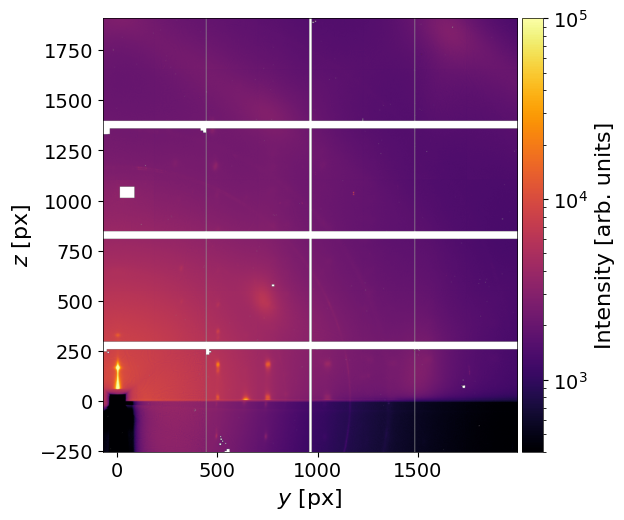

In [22]:
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data'  # dataset path
)

fig, ax = analysis.plot_img_raw(
    frame_num=7,
    clims=(4e2,1e5),
    return_fig=True,
    plot_result=True,
    save_fig=False,
    path_to_save_fig="img.png"
)

How to change the plotting defaults (colormap, font size, etc.) is described in [Tutorial 12](tutorial_12_visualization.ipynb).